In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve)

In [4]:
test = pd.read_csv("/Users/syedalihussain/Documents/customer_churn/data/processed/test.csv")

X_test = test.drop(columns=['Churn'])
y_test = test['Churn']

model = joblib.load("/Users/syedalihussain/Documents/customer_churn/models/saved_models/xgb_model.pkl")

print("Data and model loaded")

Data and model loaded


In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print('prediction done')

prediction done


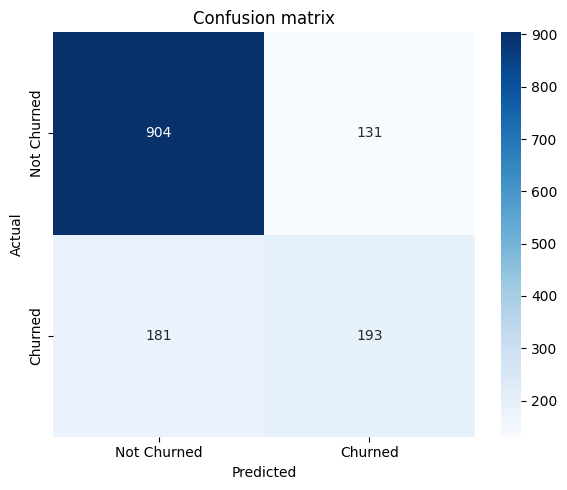

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])

plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("/Users/syedalihussain/Documents/customer_churn/report/figures/confusion_matrix.png")
plt.show()

In [8]:
# Break down what each number means
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (correctly predicted NOT churned): {tn}")
print(f"False Positives (predicted churned but actually stayed): {fp}")
print(f"False Negatives (predicted stayed but actually churned): {fn}")
print(f"True Positives  (correctly predicted churned): {tp}")

True Negatives  (correctly predicted NOT churned): 904
False Positives (predicted churned but actually stayed): 131
False Negatives (predicted stayed but actually churned): 181
True Positives  (correctly predicted churned): 193


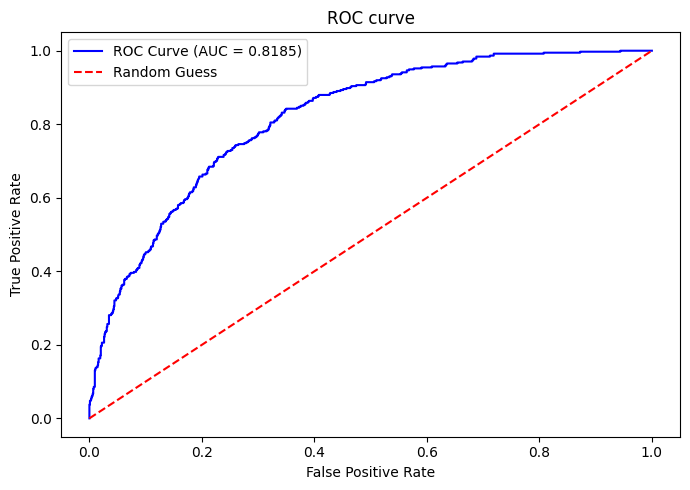

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig("/Users/syedalihussain/Documents/customer_churn/report/figures/roc_curve.png")
plt.show()

/var/folders/6q/38s__mqj0jv88pf4ms711b0r0000gn/T/ipykernel_98954/252287829.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette='Blues_r')


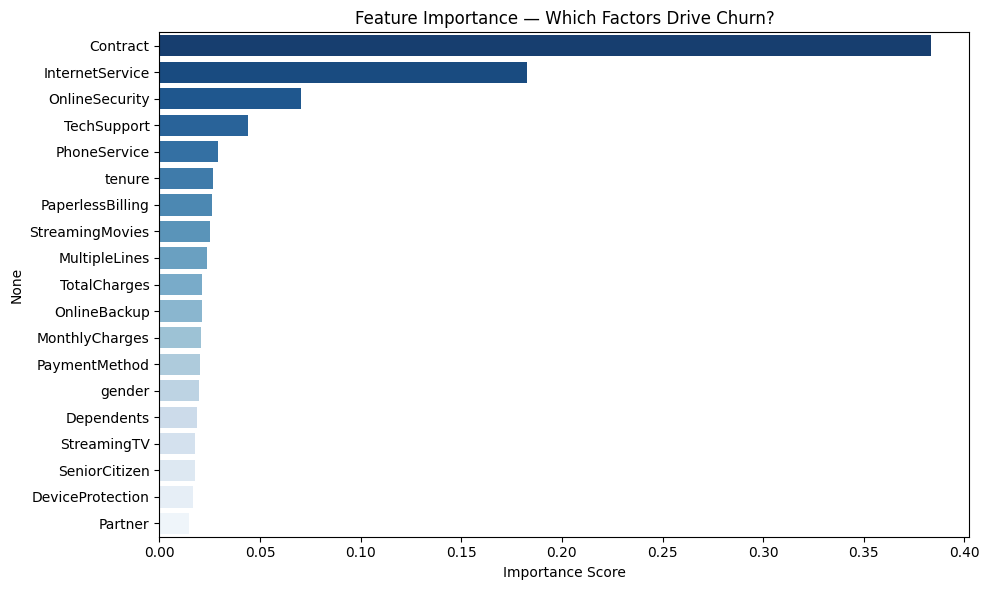

In [16]:
importance = pd.Series(model.feature_importances_, index=X_test.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, palette='Blues_r')
plt.title('Feature Importance — Which Factors Drive Churn?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("/Users/syedalihussain/Documents/customer_churn/report/figures/feature_importance.png")
plt.show()